# 21회 통계

In [10]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
import koreanize_matplotlib

warnings.filterwarnings('ignore')

**1. 다음의 데이터를 사용하여 기니피그의 치아 길이의 성장이 비타민 투여량과 투약 방법에 따라 차이가 있는지 이원배치 분산분석을 수행하시오.**

Data description

- len : 기니피그의 치아길이  
- dose : 비타민 C 투여량  
- sup : orange juice(OJ), ascorbic acid(VC)

In [64]:
df = pd.read_csv('./problem4.csv')

print(df.info())
display(df.head(3))

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 60 entries, 0 to 59
Data columns (total 3 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   len     60 non-null     float64
 1   supp    60 non-null     object 
 2   dose    60 non-null     float64
dtypes: float64(2), object(1)
memory usage: 1.5+ KB
None


,len,supp,dose
0,4.2,VC,0.5
1,11.5,VC,0.5
2,7.3,VC,0.5


데이터의 결측치는 없으며, 종속변수는 len(기니피그 치아길이) 이며, 설명변수는 supp(투약방법), dose(비타민 투여량)이다.   
supp는 카테고리 변수이며, dose는 수치형으로 보이지만 실제로는 3개의 그룹을 가진 카테고리 변수이다.

In [65]:
df.dose.value_counts()

2.0    20
1.0    20
0.5    20
Name: dose, dtype: int64

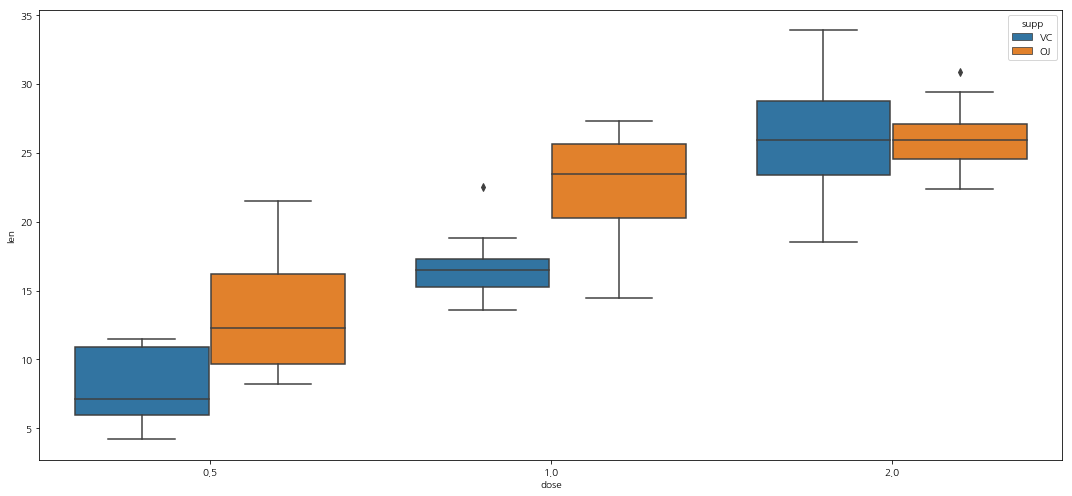

In [66]:
plt.figure(figsize=(15, 7))
sns.boxplot(x='dose', y='len', hue='supp', data=df)
plt.tight_layout()
plt.show()

각 설명변수에 따른 종속변수의 분포를 boxplot으로 나타냈다.  
- supp: 비타민 투여량이 0.5, 1인 경우는 oj의 기니피그 치아길이가 긴 경향을 보이나, 비타민 c를 충분히(2.0) 투약했을 경우에는 기니피그  
  두 방식 모두에서 기니피그 치아길이 평균은 비슷하다. 단, oj를 투약했을 경우에는 편차가 적다.
- dose(비타민 투여량): 투여량이 많을수록 기니피그 치아길이가 길어지는 경향을 보임

종속변수가 연속형 데이터이며, 2개의 설명변수가 있고, 각 설명변수는 3개의 그룹으로 분류되어 있으므로 이원배치 분산분석을 수행한다.  
단, 이원배치 분산분석은 모수검정으로 정규성, 등분산성, 독립성을 만족하여야 한다.  
이를 만족하지 못한다면 비모수방식인 Scheirer-Ray-Hare test (SRH) 를 실시한다.(또는  Aligned Rank Transform(ART) ANOVA)   
실험을 통해 수집한 데이터이므로 독립성은 만족한다고 가정한다.

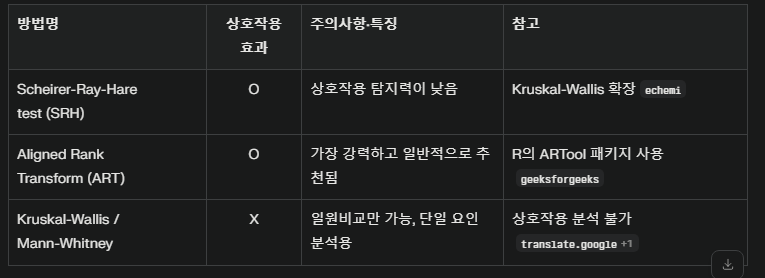

<가설수립>
- H0
  - (주효과)supp: 투약방식에 따른 기니피그 치아길이 차이가 없다.
  - (주효과)dose: 비타민 투여량에 따른 기니피그 치아길이 차이가 없다.
  - 교호작용: 투약방식과 비타민 투여량 간에는 상관관계가 없다.
- H1
  - (주효과)supp: 투약방식에 따른 기니피그 치아길이 차이가 있다.
  - (주효과)dose: 비타민 투여량에 따른 기니피그 치아길이 차이가 있다.
  - 교호작용: 투약방식과 비타민 투여량 간에는 상관관계가 있다.

먼저 데이터의 정규성, 등분산성을 만족하는지 여부를 확인한다.  
유의확률 5% 하 shapiro, levene 검정을 실시한다.

In [67]:
from scipy.stats import shapiro, levene

# 종속변수를 설명변수 그룹별로 나눠줌(3*2 = 6)
gr = [group['len'].values for name, group in df.groupby(['supp', 'dose'])]

s_rs = pd.DataFrame(columns=['cnt', 'stat', 'p-value'])

for i, g in enumerate(gr):
    s_stat, s_p = shapiro(g)
    s_rs.loc[len(s_rs)] = [i, s_stat, s_p]

l_stat, l_p = levene(*gr)

print("정규성 검정결과: 모든 조합에서 정규성 만족")
display(s_rs)
print(f"등분산성 검정 결과(p-value: {l_p:.3f}:", "등분산성 만족(귀무)" if s_p >= 0.05 else "등분산성 만족x")

정규성 검정결과: 모든 조합에서 정규성 만족


,cnt,stat,p-value
0,0.0,0.892744,0.182042
1,1.0,0.926601,0.415300
2,2.0,0.962575,0.814791
3,3.0,0.889997,0.169563
4,4.0,0.908340,0.269784
5,5.0,0.973276,0.919450


등분산성 검정 결과(p-value: 0.148: 등분산성 만족(귀무)


데이터가 정규성, 등분산성을 만족하므로 이원배치 분산분석을 수행한다.

In [68]:
import statsmodels.api as sm
import statsmodels.formula.api as smf

model = smf.ols(formula='len~C(dose)*C(supp)', data=df).fit()
anova = sm.stats.anova_lm(model, typ=3)

display(anova)

,sum_sq,df,F,PR(>F)
Intercept,1750.329000,1.0,132.729911,3.602548e-16
C(dose),885.264667,2.0,33.565433,3.363190e-10
C(supp),137.812500,1.0,10.450516,2.092470e-03
C(dose):C(supp),108.319000,2.0,4.106991,2.186027e-02
Residual,712.106000,54.0,NaN,NaN


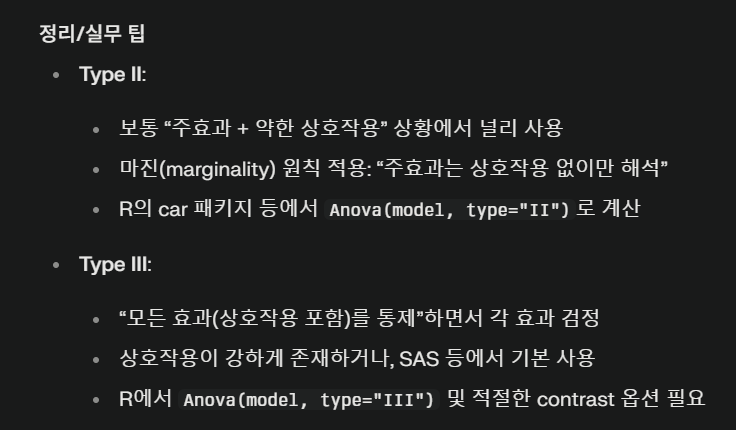

먼저 교호작용 검정결과를 확인한다. 두 설명변수 간 교호작용 p-value가 약 0.022로 유의확률 5% 하에서 귀무가설을 기각하므로  
투약방식과 비타민 투여량 간에는 상관관계가 있다는 것이 통계적으로 유의하다.  
이는 두 설명변수가 종속변수에 미치는 영향이 서로 독립적이지 않고 서로 영향을 주고받는다는 의미로, 한 변수의 효과가 다른 변수의  
수준에 따라 달라지므로 각 설명변수의 주효과 검정은 주의하여 해석하여야 한다.  

두 독립변수의 주성분 결과도 귀무가설을 기각하므로 대립가설을 만족하나,    
- 투약방식에 따른 기니피그 치아길이 차이가 있다.  
- 비타민 투여량에 따른 기니피그 치아길이 차이가 있다. 
box plot으로 각 독립변수-종속변수 간 그룹 값 분포를 시각화하여 판단해본다. 
- dose-len: 각 그룹 간 종속변수 차이가 확연하므로 대립가설을 만족한다고 볼 수 있음  
- supp-len: 중앙값 기준으로는 OJ 가 더 높은 값이나, 각 그룹 내 편차가 커서 분류가 모호함  


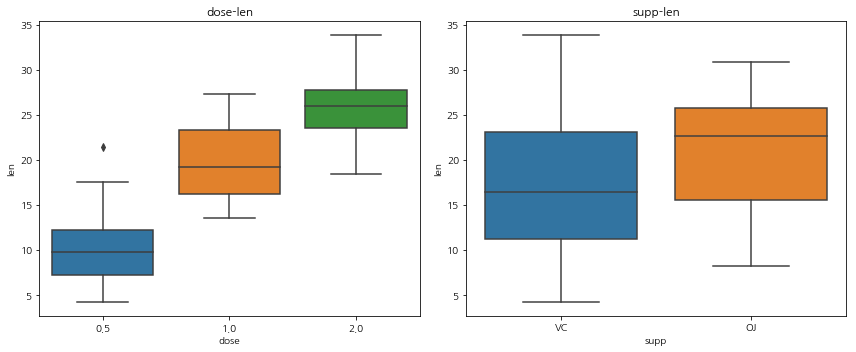

In [69]:
fig, ax = plt.subplots(1, 2, figsize=(12, 5))
sns.boxplot(x='dose', y='len', data=df, ax=ax[0])
ax[0].set_title('dose-len')
sns.boxplot(x='supp', y='len', data=df, ax=ax[1])
ax[1].set_title('supp-len')
plt.tight_layout()
plt.show()

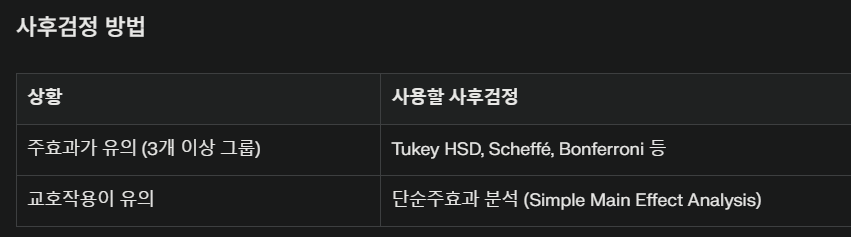

주효과는 교호작용이 있을 때 단독으로 해석하기 어려움

교호작용이 있다는 것은 "한 변수의 효과가 다른 변수 수준에 따라 달라진다"는 의미이기 때문이다.   
따라서 한 독립변수의 특정 수준에서 다른 독립변수가 종속변수에 미치는 영향의 효과를 확인하기 위해(교호작용의 구체적 패턴을 확인하기   
위해, "조건을 고정하고 분석하는 방법인 단순 주효과 분석을 수행한다.

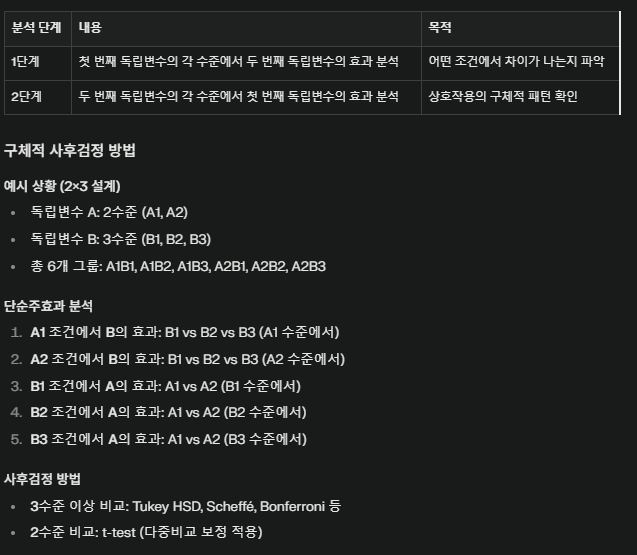

In [77]:
import pingouin as pg

#  단순 주효과 분석
## 투약유형 수준별 투약량 비교(3수준이므로 Tukey HSD)
for level in df['supp'].unique():
    print(f"단순 주효과: supp[{level}]에서 dose 효과")
    rse = pg.pairwise_tukey(dv='len', between='dose', data=df[df['supp'] == level])
    display(rse)

## 투약량(dose) 수준별 투약유형 비교(2수준이므로 t-test)
for level in df['dose'].unique():
    print(f"단순 주효과: dose[{level}]에서 supp 효과")
    sub = df[df['dose']==level]
    rse = pg.ttest(sub[sub['supp'] == 'VC']['len'], 
                   sub[sub['supp'] == 'OJ']['len'], 
                   paired=False)
    display(rse)


단순 주효과: supp[VC]에서 dose 효과


,A,B,mean(A),mean(B),diff,se,tail,T,p-tukey,hedges
0,0.5,1.0,7.98,16.77,-8.79,1.568205,two-sided,-5.605135,0.001,-2.400776
1,0.5,2.0,7.98,26.14,-18.16,1.568205,two-sided,-11.580119,0.001,-4.959965
2,1.0,2.0,16.77,26.14,-9.37,1.568205,two-sided,-5.974984,0.001,-2.559189


단순 주효과: supp[OJ]에서 dose 효과


,A,B,mean(A),mean(B),diff,se,tail,T,p-tukey,hedges
0,0.5,1.0,13.23,22.70,-9.47,1.677973,two-sided,-5.643715,0.001000,-2.417300
1,0.5,2.0,13.23,26.06,-12.83,1.677973,two-sided,-7.646131,0.001000,-3.274970
2,1.0,2.0,22.70,26.06,-3.36,1.677973,two-sided,-2.002416,0.115425,-0.857669


단순 주효과: dose[0.5]에서 supp 효과


,T,dof,tail,p-val,CI95%,cohen-d,BF10,power
T-test,-3.169733,18,two-sided,0.005304,"[-8.73, -1.77]",1.417548,8.278,0.850091


단순 주효과: dose[1.0]에서 supp 효과


,T,dof,tail,p-val,CI95%,cohen-d,BF10,power
T-test,-4.03277,18,two-sided,0.000781,"[-9.02, -2.84]",1.803509,36.544,0.967816


단순 주효과: dose[2.0]에서 supp 효과


,T,dof,tail,p-val,CI95%,cohen-d,BF10,power
T-test,0.046136,18,two-sided,0.96371,"[-3.56, 3.72]",0.020633,0.398,0.050219


유의수준 5% 하에서 p-value 의 통계적 유의성을 확인한다.  

1. 투약유형 수준별 투약량 비교(3수준이므로 Tukey HSD) 
- supp를 VC로 고정했을 때: 모든 투약량 쌍에서 귀무가설 기각, 투약량에 따른 차이가 유의하다.  
- supp를 OJ로 고정했을 때: 투약량 1 - 2 쌍에서 귀무가설을 기각할 수 없음. 따라서 투약량 1, 2일 때 기니피그 치아길이 차이가 없다.  

2. 투약량(dose) 수준별 투약유형 비교(2수준이므로 t-test)  
- dose 0.5 고정: 귀무가설 기각, 투약량 0.5일 때 투약방식에 따른 치아길이 차이가 있다.  
- dose 1.0 고정: 귀무가설 기각, 투약량 1.0일 때 투약방식에 따른 치아길이 차이가 있다.  
- dose 1.5 고정: 귀무가설 기각불가, 투약량 1.5일 때 투약방식에 따른 치아길이 차이가 없다. 

#  22회

1. 한 중소기업이 새로운 IoT 장비를 개발하여 생산에 도입했습니다. 이 장비는 각기 다른 200개의 장치가 다양한 환경에서 작동하며,   
각 장치의 성능과 오류 발생률을 모니터링하는 것이 기업의 주요 과제가 되었습니다.   
이를 통해 장치의 신뢰성을 평가하고, 문제가 발생할 경우 신속히 대응하기 위해 p 관리도를 사용하기로 했습니다.  

이 기업은 각 장치가 100번의 작동을 수행한다고 가정하고, 각 장치의 작동 중 발생한 오류 수를 기록했습니다.  
데이터는 장치 번호에 따라 정리되었으며, 이 정보는 공정이 안정적인지 여부를 파악하고,  
특정 장치가 비정상적으로 많은 오류를 발생시키는지 확인하기 위해 사용됩니다.

In [57]:
df = pd.read_csv('./problem2.csv')

print(df.info())

display(df.head(3))

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 2 columns):
 #   Column             Non-Null Count  Dtype
---  ------             --------------  -----
 0   iot_number         200 non-null    int64
 1   error_case_number  200 non-null    int64
dtypes: int64(2)
memory usage: 3.2 KB
None


,iot_number,error_case_number
0,1,3
1,2,8
2,3,4


p 관리도는 품질관리에서 사용하는 통계적 관리도로, 샘플 내에서 불량품(결함있는 제품)의 비율(Proportion)을 시간이나 순서에 따라   
모니터링하여 공정이 안정적인 상태인지 평가하는 도구. 즉, 각각의 검사 단위에서 불량품이 차지하는 비율이 공정의 허용범위 내에 있어  
정상적인지 아니면 비정상적인 변동이 발생했는지 판단할 수 있음

- p 관리도는 각 샘플별 불량품 비율을 점으로 표시하며, 중심선(Center Line, 평균 불량률)과 상/하한 관리한계선(UCL, LCL)이 함께 표시
- 샘플 크기가 다를 수도 있고, 그에 맞게 관리한계선이 조정
- 공정 중에 어떤 점이 관리한계선을 벗어나면 공정에 이상이 있다고 판단하여 원인을 조사

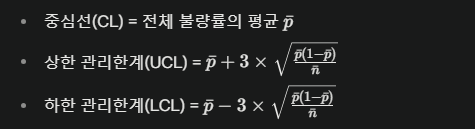

In [58]:
df['error_rate'] = df['error_case_number']/100 #100회 가동 시의 오류수이므로
center_line = df['error_rate'].mean() #중심선(평균불량률)
ucl = center_line + 3*np.sqrt((center_line*(1-center_line))/len(df))
lcl = center_line - 3*np.sqrt((center_line*(1-center_line))/len(df)) #음수일 경우 0으로 조정 필요

print('중심선:', center_line.round(3))
print("상한 관리한계: ", ucl.round(3))
print("하한 관리한계: ", lcl.round(3))

중심선: 0.051
상한 관리한계:  0.097
하한 관리한계:  0.004


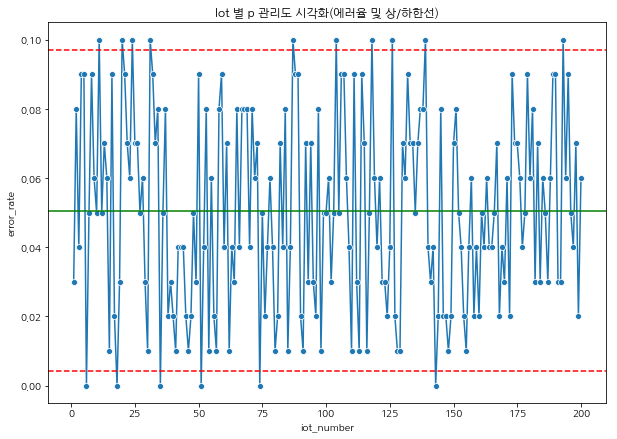

In [61]:
plt.figure(figsize=(10, 7))

sns.lineplot(data=df, x='iot_number', y='error_rate', marker='o')
plt.axhline(y=ucl, color='r', ls='--')
plt.axhline(y=center_line, color='g', ls='-')
plt.axhline(y=lcl, color='r', ls='--')
plt.title('lot 별 p 관리도 시각화(에러율 및 상/하한선)')
plt.show()

In [60]:
df[(df['error_rate'] > ucl) | (df['error_rate'] < lcl) ]

,iot_number,error_case_number,error_rate
5,6,0,0.0
10,11,10,0.1
17,18,0,0.0
19,20,10,0.1
23,24,10,0.1
30,31,10,0.1
34,35,0,0.0
50,51,0,0.0
73,74,0,0.0
86,87,10,0.1


하한 관리한계 미만, 상한 관리한계 초과 데이터를 이상치로 판단한다. 16개의 데이터가 이에 해당하며,  
전체 데이터의 8%가 비정상적인 변동의 에러율이라고 볼 수 있다.   
각 lot별 공정 간 허용범위 밖을 벗어나는(공정에 이상이 있는) lot번호를 쉽게 식별할 수 있다.  
- 공정에 이상이 있는 lot: 6,  11,  18,  20,  24,  31,  35,  51,  74,  87, 104, 118, 126, 139, 143, 193

2. 한 식품 회사가 두 가지 제품, 제품 A와 제품 B를 생산하고 있습니다. 이 두 제품은 각각 P와 Q라는 두 가지 주요 원재료를 사용하며,   
   회사는 원재료와 생산 능력을 고려해 이익을 극대화하려고 합니다.  
   ☞ 이익을 극대화한다는 것은 자원 사용률을 최소화한 상태에서 생산갯수를 늘린다는 것

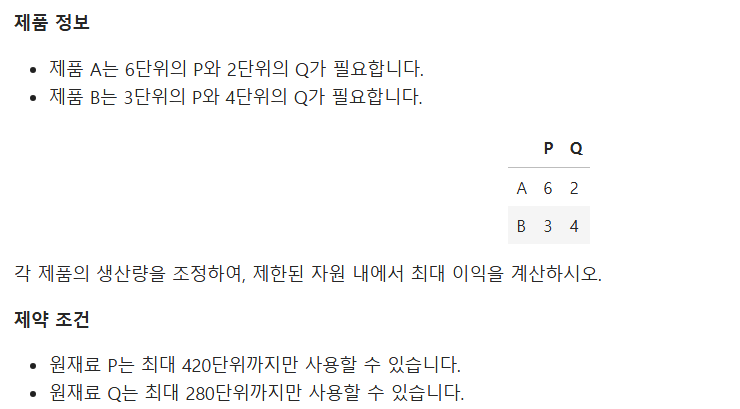

- X: 제품 A 의 생산갯수 / Y: 제품 B의 생산갯수

- 목적함수: 이익단가 
  이익(max): 900X + 600Y  (이것이 반드시 주어져야 함)
  
- 제약조건
  - P: 6X + 3Y <= 420 
  - Q: 2X + 4Y <= 280
  
해당문제는 Scipy.optimize의 linprog 부등식 문제로 해결할 수 있다.

In [62]:
from itertools import product
from scipy.optimize import linprog

#비용함수 
cost = [-900, -600] #min 문제를 max 문제로 바꿈

#제약조건
p_const = [420]
q_const = [280]

#제약조건에 따른 매트릭스
A_ub = [[6, 3], [2, 4]]

B_ub = np.concatenate([p_const, q_const])

rs = linprog(c=cost, A_ub = A_ub, b_ub = B_ub, bounds=[(0, None)]*2, method='highs')

In [130]:
print(f"최적의 생산경비: {-round(rs.fun)} 원")
label = ['A', 'B'] #공장_지역
mx = pd.DataFrame(rs.x, index= ['A공장 수량', 'B공장 수량'],columns=['생산수량'])
mx['생산수량(int)'] = [47, 46] #A 공장의 이득이 더 높으므로 A를 높임
display(mx)

print("다시 계산한 최적의 생산경비:", 900*47+600*46, "원")

최적의 생산경비: 70000 원


,생산수량,생산수량(int)
A공장 수량,46.666667,47
B공장 수량,46.666667,46


다시 계산한 최적의 생산경비: 69900 원


생산수량은 실수가 없다. 그리고 생산수량에 대한 최적화 문제는 다음의 라이브러리가 더 적당해보인다.

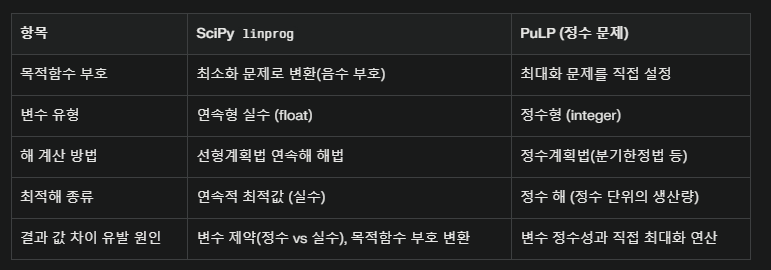

In [131]:
import pulp

prob = pulp.LpProblem('최대 이익', pulp.LpMaximize) #pulp.LpMinimize 등
x = pulp.LpVariable('x', lowBound=0, cat='Integer') #A 생산량
y = pulp.LpVariable('y', lowBound=0, cat='Integer') #B 생산량

prob += 900*x + 600* y
prob += 6*x + 3*y <= 420
prob += 2*x + 4*y <= 280

prob.solve()

optim = [pulp.value(x), pulp.value(y)] #최적해(공장별 생산갯수)
o_value = pulp.value(prob.objective) #최대 이익

print(f"공장별 최적 생산갯수: {optim}")
print(f"공장별 최대 이익: {o_value}")

공장별 최적 생산갯수: [47.0, 46.0]
공장별 최대 이익: 69900.0


3. 금속 성분 함유량 데이터 ‑ 제품에 금속 재질 함유량의 분산이 1.3을 넘으면 불량이라고 보고 있는데, 제조사별로 차이가 난다고   
   제보를 받았다. 주어진 회사 제품의 분산에 대해 검정을 수행하시오. (유의수준 5%)

In [137]:
df = pd.read_csv('./problem42.csv')

print(df.info())
display(df.head(3))

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 30 entries, 0 to 29
Data columns (total 1 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   x       30 non-null     float64
dtypes: float64(1)
memory usage: 368.0 bytes
None


,x
0,9.060319
1,10.275465
2,8.746557


모분산값 1.3에 대한 분산값과 일치하는지 여부를 묻는 모분산 분산검정인 카이제곱 검정을 수행한다.  

<가설수립>  
- H0: 데이터의 분산이 1.3 이하이다. 
- H1: 데이터의 분산이 1.3을 초과한다.(우측검정)

In [154]:
from scipy.stats import chi2

n = len(df) #데이터갯수
v = df.var(ddof=1)
v0 = 1.3 #제시된 모분산
ddof = n-1 # 자유도
alpha = 0.05

c_stats = ddof*v/v0

p = 1-chi2.cdf(c_stats, ddof)[0]

print(f"유의수준 5% 하 카이제곱 검정결과({p:.3f}) 귀무가설", "기각" if p <=0.05 else "기각x")

유의수준 5% 하 카이제곱 검정결과(0.047) 귀무가설 기각


유의수준 5% 하 귀무가설을 기각한다. 따라서 데이터의 분산이 1.3을 초과하므로 불량이다.

3. 구매하는 패턴으로 봐서 두 상품이 연관이 있는지 가설을 세우고 검정하시오.
→ 패턴이 연관이 없는지(무작위로 추출되었는지), 연관이 있는지 여부를 검정하므로  
   비모수검정인 일표본 run-test를 수행한다.
   
<가설수립>
- H0: 구매패턴에서 두 상품의 연관성이 없다.(무작위)
- H1: 구매패턴에서 두 상품의 연관성이 있다. 

In [160]:
run_sample = ["A", "A", "A", "B", "B", "A", "A", "A", "A", 
              "B", "A", "B", "B", "B", "A", "A", "A", "A", 
              "B", "B", "A", "A", "A", "B", "B"]

c_r = np.where([x == 'A' for x in run_sample], 1, 0)

In [164]:
from statsmodels.sandbox.stats.runs import runstest_1samp

stats, p = runstest_1samp(c_r, cutoff='median')

print(f"검정통계량: {stats}")
print(f"p-value: {p:.3f}, ", "대립가설" if p < 0.05 else "귀무가설")

검정통계량: -1.0660035817780522
p-value: 0.286,  귀무가설


유의확률 5% 하에서 p-value가 충분히 크므로 귀무가설을 기각할 수 없다.  
따라서 구매패턴에서 두 상품의 연관성이 없다.

# 23회

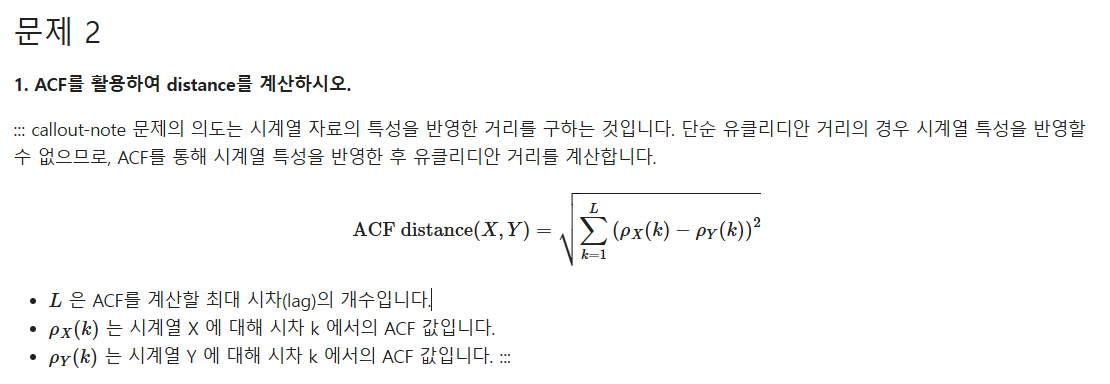

ACF(자기상관함수)**는 시계열 내에서 각 시차(lag)별로 값과 과거값이 얼마나 유사한지(상관성이 있는지)를 0~1의 값으로 환산하는 함수

In [87]:
df = pd.read_csv("./problem2.csv")
df.head()

,country,date,confirmed
0,Belarus,2020-01-22,0
1,Belarus,2020-01-23,0
2,Belarus,2020-01-24,0
3,Belarus,2020-01-25,0
4,Belarus,2020-01-26,0


In [88]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3317 entries, 0 to 3316
Data columns (total 3 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   country    3317 non-null   object
 1   date       3317 non-null   object
 2   confirmed  3317 non-null   int64 
dtypes: int64(1), object(2)
memory usage: 77.9+ KB


In [89]:
df['date']=pd.to_datetime(df['date'])

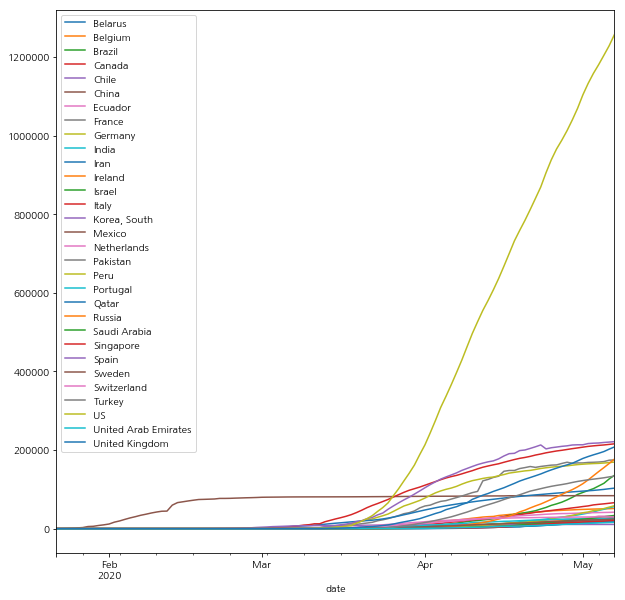

In [90]:
dat = df.pivot(index='date', columns='country', values='confirmed')
dat.plot(figsize=(10, 10));
plt.legend(loc='upper left', prop={'size': 10});
plt.show();

미국의 경우 100만명 이상의 누적확진자 존재함.   
정상성 여부 확인을 위해 adf 검정 실시

In [100]:
from statsmodels.tsa.stattools import adfuller, kpss
from statsmodels.graphics.tsaplots import plot_pacf, plot_acf
from statsmodels.graphics.tsaplots import acf

rs = adfuller(df['confirmed'])

print(f"유의수준 5% 하 통계량: {rs[0]:.3f} / p-value: {rs[1]:.3f}")

유의수준 5% 하 통계량: 1.569 / p-value: 0.998


정상성을 만족하지 않으므로 차분 수행

In [101]:
df['diff'] = df['confirmed'].diff(1

In [102]:
rs = adfuller(df['diff'].dropna())

print(f"유의수준 5% 하 통계량: {rs[0]:.3f} / p-value: {rs[1]:.3f}")

유의수준 5% 하 통계량: -9.255 / p-value: 0.000


정상성을 만족하므로 acf를 계산한다. 

In [122]:
df = df.drop(columns='confirmed', inplace=True)

,country,date,diff
0,Belarus,2020-01-22,NaN
1,Belarus,2020-01-23,0.0
2,Belarus,2020-01-24,0.0
3,Belarus,2020-01-25,0.0
4,Belarus,2020-01-26,0.0
...,...,...,...
3312,US,2020-05-03,25501.0
3313,US,2020-05-04,22335.0
3314,US,2020-05-05,23976.0
3315,US,2020-05-06,24252.0


In [125]:
from scipy.spatial.distance import pdist, squareform

# 1) 국가별로 그룹화 후 ACF 벡터 계산
acf_dict = {}
nlags = 40  # 최대 lag 수

for country, sub in df.groupby('country'):
    # 1-1) 차분 시계열(이미 diff 컬럼)에서 NaN 제거
    diff_ts = sub.set_index('date')['diff'].dropna()
    
    # 1-2) ACF 계산
    acf_vals = acf(diff_ts, nlags=nlags, fft=False)[1:] # lag 0은 자기 자신이므로 빼줌
    acf_dict[country] = acf_vals

# 2) ACF 벡터를 쌓아 거리 계산
countries = list(acf_dict.keys())
acf_matrix = np.vstack([acf_dict[c] for c in countries])

# 2-1) 유클리디안 거리 행렬 생성
dist_array = pdist(acf_matrix, metric='euclidean')
dist_matrix = squareform(dist_array)

# 3) 결과를 DataFrame으로 정리
dist_df = pd.DataFrame(dist_matrix, index=countries, columns=countries)

print("차분(diff) 후 ACF 기반 국가 간 거리 행렬:")
display(dist_df)

차분(diff) 후 ACF 기반 국가 간 거리 행렬:


,Belarus,Belgium,Brazil,Canada,Chile,China,Ecuador,France,Germany,India,...,Russia,Saudi Arabia,Singapore,Spain,Sweden,Switzerland,Turkey,US,United Arab Emirates,United Kingdom
Belarus,0.000000,2.189609,2.095709,2.489316,2.499395,2.268868,2.499378,1.823195,2.440600,2.500387,...,0.701512,2.508918,2.471347,0.974940,2.512495,2.402805,1.662680,1.427984,2.512116,0.712807
Belgium,2.189609,0.000000,0.116167,0.315758,0.327340,0.597475,0.328060,0.424707,0.262898,0.329414,...,1.517835,0.338977,0.300176,1.296012,0.342613,0.226535,0.534334,0.854242,0.342426,1.974055
Brazil,2.095709,0.116167,0.000000,0.406626,0.417471,0.574587,0.418207,0.356067,0.354928,0.419341,...,1.420340,0.428785,0.389659,1.209205,0.432563,0.317877,0.451206,0.777032,0.432306,1.893720
Canada,2.489316,0.315758,0.406626,0.000000,0.012113,0.603251,0.014719,0.703422,0.053761,0.015222,...,1.817734,0.024904,0.019221,1.575532,0.028405,0.089848,0.845650,1.169510,0.028412,2.289190
Chile,2.499395,0.327340,0.417471,0.012113,0.000000,0.604444,0.006938,0.713487,0.065610,0.004272,...,1.827865,0.013276,0.028615,1.584729,0.016773,0.101300,0.856717,1.181107,0.016796,2.300655
China,2.268868,0.597475,0.574587,0.603251,0.604444,0.000000,0.603399,0.703232,0.592831,0.603332,...,1.619417,0.605509,0.590611,1.377276,0.607383,0.578635,0.839427,1.164748,0.606918,2.197117
Ecuador,2.499378,0.328060,0.418207,0.014719,0.006938,0.603399,0.000000,0.713807,0.066898,0.006459,...,1.828119,0.012975,0.029425,1.584286,0.016357,0.102139,0.857019,1.181841,0.016301,2.301277
France,1.823195,0.424707,0.356067,0.703422,0.713487,0.703232,0.713807,0.000000,0.656288,0.714591,...,1.162710,0.723000,0.686570,0.939254,0.726439,0.620146,0.268714,0.580252,0.726105,1.649247
Germany,2.440600,0.262898,0.354928,0.053761,0.065610,0.592831,0.066898,0.656288,0.000000,0.068297,...,1.768463,0.078155,0.040752,1.530822,0.081808,0.037960,0.794142,1.116538,0.081731,2.236647
India,2.500387,0.329414,0.419341,0.015222,0.004272,0.603332,0.006459,0.714591,0.068297,0.000000,...,1.829026,0.009962,0.030189,1.585096,0.013699,0.103455,0.858288,1.183215,0.013599,2.302592


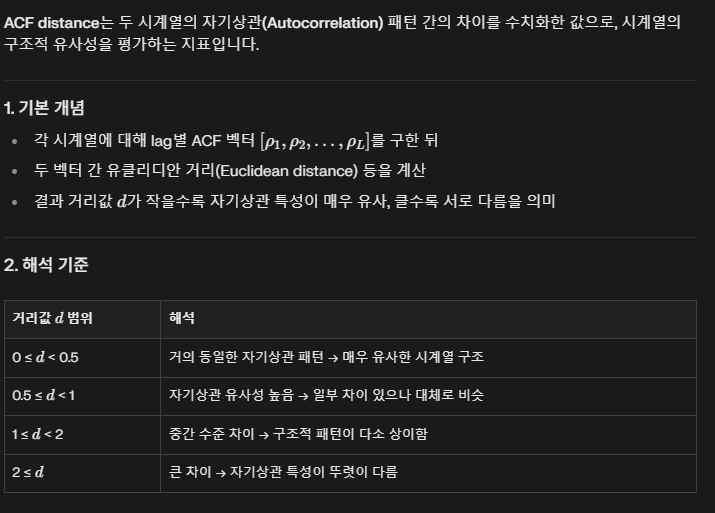

따라서 국가 간 acf distance 가 작다면 두 국가는 매우 유사한 시계열 구조를 가지며,  
값이 크다면 이질적인 시계열 구조를 가진다고 볼 수 있다.

2. 계층적 군집 분석을 위한 덴드로그램을 작성하시오.

최적 군집 수: 2, 실루엣 계수: 0.766


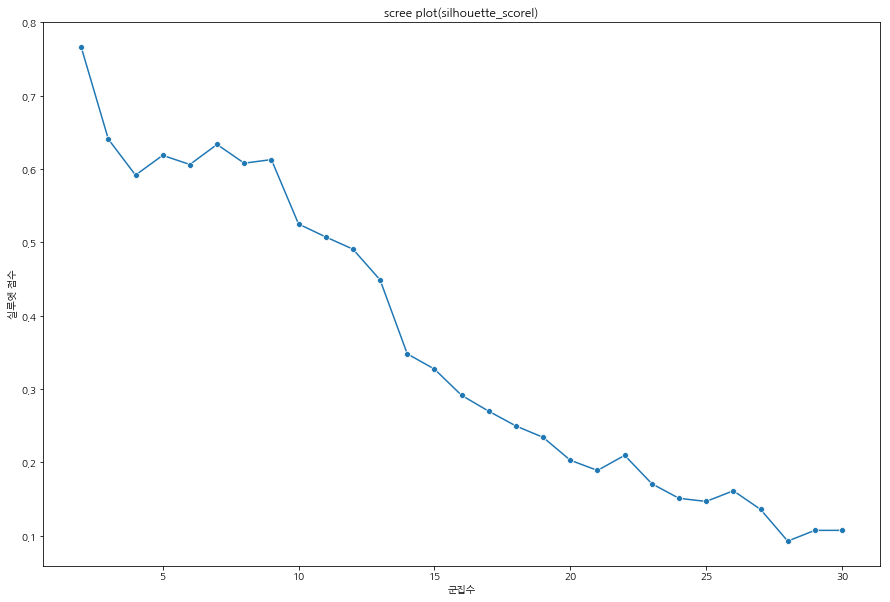

In [145]:
from sklearn.metrics import silhouette_score
from scipy.cluster.hierarchy import linkage, dendrogram, fcluster

best_k = 2 #초기값
best_score = -1 #초기값
s_list = []
Z_tmp = linkage(dist_df, 'ward') #링키지 매트릭스


for k in range(2, len(countries)):
    labels = fcluster(Z_tmp, t=k, criterion='maxclust')
    score = silhouette_score(dist_df, labels, metric='precomputed')
    s_list.append(score)
    if score > best_score:
        best_score, best_k = score, k
print(f"최적 군집 수: {best_k}, 실루엣 계수: {best_score:.3f}")
plt.figure(figsize=(15, 10))
sns.lineplot(x=np.arange(2, len(s_list)+2), y=s_list, marker='o')
plt.title('scree plot(silhouette_scorel)')
plt.xlabel('군집수')
plt.ylabel('실루엣 점수')
plt.show()

군집이 2일 때 실루엣 계수: 0.766로 가장 높으므로 군집의 수를 2로 분류한다. 

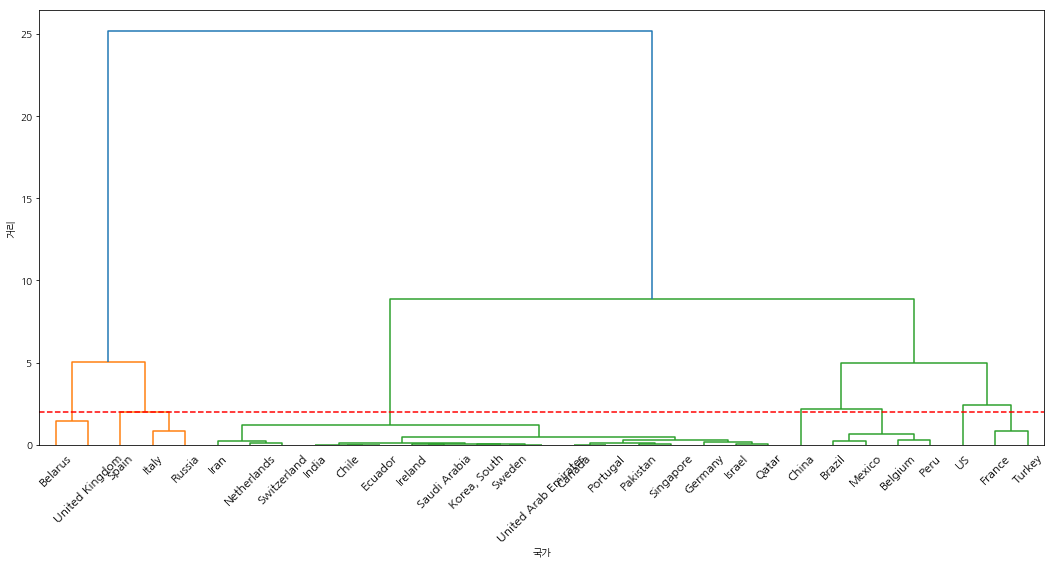

In [154]:
#군집화 결과 시각화
z = linkage(dist_df, 'ward') 

plt.figure(figsize=(18, 8))
dendrogram(z, labels=dist_df.index) #해당 거리값 기준 색상이 다른 군집들로 나눠줌
plt.axhline(y=2, ls='--', color='r')
plt.xlabel('국가')
plt.ylabel('거리')
plt.xticks(fontsize=12)
plt.show()

벨루스, 영국, 스페인, 이탈리아, 러시아와 나머지 국가로 2 군집의 계층적 군집이 분류되었다.  
같은 군집에 속한 각 국가의 시계열 데이터의 유사도가 높다고 할 수 있겠다.

ACF distance를 이용해 국가별 시계열 간 유사도를 비교할 때는 **차분을 통해 정상성(stationarity)을 확보하는 것이 권장**됩니다. 이유는 다음과 같습니다.

1. 비정상 시계열의 ACF 특성 왜곡  
   - 비정상(non-stationary) 시계열은 자기상관함수(ACF)가 느리게 감소하거나 일정하게 높은 값을 유지해, “패턴”이 실제보다 과장되거나 서로 다른 구조를 왜곡합니다.  
   - 예컨대, 모든 국가 시계열이 공통의 장기 상승 추세를 가지면 ACF가 강하게 남아 유사도가 과도하게 높게 측정될 수 있습니다.

2. 정상성 확보의 효과  
   - 차분(differencing)을 통해 추세(trend)나 비정상 분산 문제를 제거하면, 시계열 고유의 **주기성·계절성·단기 변동 패턴**이 ACF에 반영됩니다.  
   - 이렇게 얻은 ACF 벡터로 거리(유클리디안, 코사인 등)를 계산하면, 국가별 **동적 패턴 유사도**를 더 정확히 비교할 수 있습니다.

3. 실무 관례  
   - 대부분의 시계열 유사도 비교 및 클러스터링 연구에서 “단위근(unit-root) 검정 → 필요 시 차분 → ACF/PACF 기반 거리 계산” 순서가 표준 워크플로우로 자리 잡고 있습니다.  
   - 특히 COVID-19 확진자처럼 명백한 상승 추세가 있는 시계열은 차분 없이는 ACF distance가 대부분 작은 값(즉, 모두 유사)만 내기 쉽습니다.

4. 예외적 경우  
   - 모든 시계열이 이미 정상성을 만족한다거나, 비교 대상이 **추세 자체**일 때(예: 장기 성장률 비교)에는 차분을 생략할 수 있습니다.  
   - 하지만 일반적으로 “패턴(자기상관 구조) 유사도” 자체를 보고 싶으면 **차분을 수행하는 편이 매우 유리**합니다.

***

**결론:**  
국가별 시계열 간 ACF distance로 유사도를 비교할 때는, 시계열이 정상성을 만족하지 않으면 **1차(또는 계절) 차분**을 통해 정상성 확보 후 ACF distance를 계산하는 것이 정확하고 해석에도 일관성을 줍니다.

1. 슬통제약의 신약이 심장 질환 환자의 혈압을 낮출 수 있는지 검증하려고 한다.   
표본으로 15명의 환자가 선택되었으며, 약을 복용하기 전과 복용한 후의 혈압을 측정하였다.  
약이 혈압을 실제로 낮추는 것인지 검증하기 위해 유의수준 5%에서 부호 검정을 수행하시오.

In [166]:
df = pd.read_csv('./problem3.csv')

print(df.info())
display(df.head(3))

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 15 entries, 0 to 14
Data columns (total 2 columns):
 #   Column     Non-Null Count  Dtype
---  ------     --------------  -----
 0   before_np  15 non-null     int64
 1   after_np   15 non-null     int64
dtypes: int64(2)
memory usage: 368.0 bytes
None


,before_np,after_np
0,130,125
1,125,120
2,120,115


동일한 환자를 대상으로 조건을 변경하여 측정한 데이터이므로 대응표본이다.  
유의수준 5% 하에서 부호검정을 수행한다. Wilcoxon 부호순위 검정도 수행할 수 있다.   
데이터가 100 이하이므로 부호검정 통계량은 이항분포를 따른다.  

<가설수립: right 검정> 전 > 후
- H0: 약을 복용하기 전과 복용 후의 혈압은 차이가 없거나, 복용 후가 더 높다.
- H1: 약을 복용하기 전보다 복용 후의 혈압이 낮다.

In [169]:
from scipy.stats import binom

diff = df['before_np'] - df['after_np'] #전후 차이
m0 = 0 #표본평균(기준값)
minus = np.sum(diff < m0) #복용 후가 더 큰 경우
plus = np.sum(diff > m0) #복용 전이 더 큰 경우
n = plus + minus
print("유효한 데이터개수:", plus)


p = binom.sf(plus-1, n, 0.5)

print(f"유의수준 5% 하 p-value {p:.3f}로", "귀무가설" if p >= 0.05 else "대립가설")

유효한 데이터개수: 12
유의수준 5% 하 p-value 0.006로 대립가설


따라서, 약을 복용하기 전보다 복용 후의 혈압이 낮다.라는 가설은 통계적으로 유의성이 있다.  
약이 혈압을 낮추는데 효과가 있다고 할 수 있다.

3. 
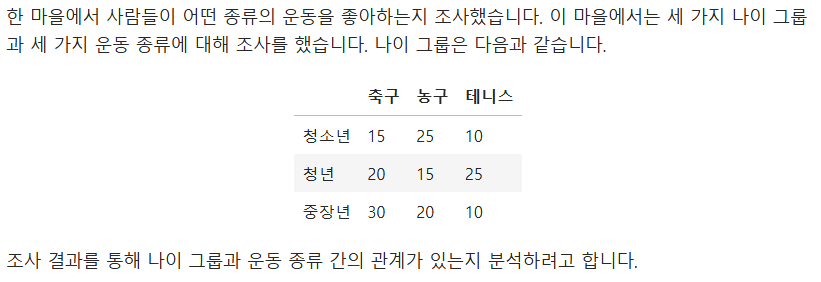

In [170]:
df = pd.DataFrame([[15, 25, 10],
                 [20, 15, 25],
                 [30, 20, 10]],
                index=['청소년', '청년', '중장년'],
                columns=['축구', '농구', '테니스'])

display(df)

,축구,농구,테니스
청소년,15,25,10
청년,20,15,25
중장년,30,20,10


한 모집단의 독립적인 두 명목변수, 각 명목변수는 3개의 그룹을 가지고 있으모,  
각 명목변수간 관계성에 대한 분석이므로 카이제곱 독립성 검정을 수행한다.  
(유의확률 5% 하 시행)

<가설수립>
- H0: 나이그룹과 운동종류 간에는 관계가 없다.(독립)
- H1: 나이그룹과 운동종류 간에는 연관성이 있다.

In [174]:
from scipy.stats import chi2_contingency

stats, p, ddof, expected = chi2_contingency(df)

print(f"카이제곱 통계량: {stats:.3f}, 자유도{ddof}")
print(f"유의수준 5% 하 p-value {p:.3f}로", "귀무가설" if p >= 0.05 else "대립가설")

카이제곱 통계량: 16.570, 자유도4
유의수준 5% 하 p-value 0.002로 대립가설


유의수준 5% 하에서 귀무가설을 기각하고 대립가설을 채택한다.  
따라서 나이그룹과 운동종류 간에는 연관성이 있다. 는 통계적으로 유의성이 있다.

### 독립일 경우의 기대빈도를 구하시오.  독립이 아님....

In [172]:
ex = pd.DataFrame(expected, index=df.index, columns=df.columns)
display(ex)

,축구,농구,테니스
청소년,19.117647,17.647059,13.235294
청년,22.941176,21.176471,15.882353
중장년,22.941176,21.176471,15.882353
